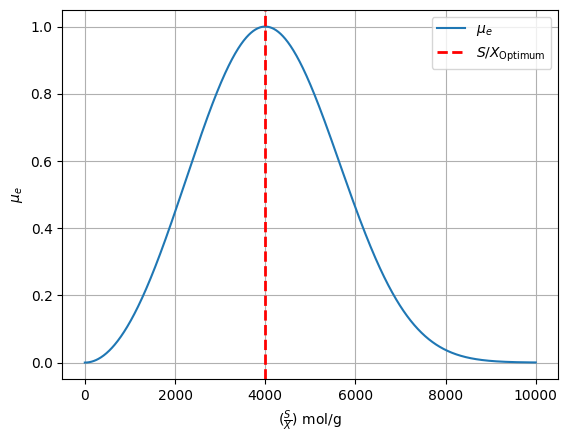

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import pandas as pd

# Define the shape parameter
k = 3 # Smaller shape parameter to widen the curve

# Compute the scale parameter to have a peak at 2500
lambda_ = 4000/ ((k - 1) / k)**(1 / k)

# Generate x values with a wider range
x = np.linspace(0, 10000, 1000)  # Increased range from 0 to 140000

# Compute the PDF
pdf = weibull_min.pdf(x, k, scale=lambda_)

# Normalize the PDF to range from 0 to 1
pdf = pdf / np.max(pdf)

# Find the x value where pdf is maximum
max_index = np.argmax(pdf)
scr_opt = x[max_index]

# Plot the distribution
plt.plot(x, pdf, label=r'$\mu_e$')
plt.xlabel(r'($\frac{S}{X}$) mol/g')
plt.ylabel(r'$\mu_e$')
#plt.title('Weibull Distribution of Enzyme Production')
plt.axvline(x=scr_opt, color='r', linestyle='--', linewidth=2, label=r'$S/X_{{\mathrm{Optimum}}}$')
#plt.axvline(x=7700, color='g', linestyle='--', linewidth=2, label='Initial SCR = 7700 mol/g')
plt.legend()
plt.grid(True)
plt.show()



In [20]:
dt = {
    'x': x,
    'pdf': pdf
}

df = pd.DataFrame(dt)

df.to_csv('pdfcsv.csv')

0.0012173210952034674


Text(0.5, 1.0, 'Peak at: 4000.0')

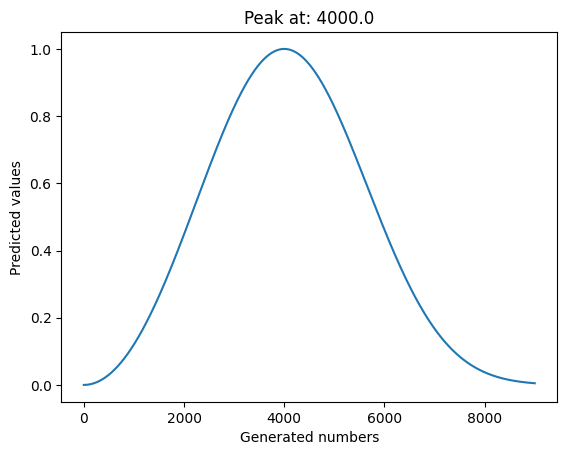

In [21]:
from scipy.interpolate import CubicSpline

# Create a cubic spline interpolation model
cs = CubicSpline(x, pdf)

# Define a function to get interpolated value
def get_interpolated_value(new_x):
    return cs(new_x)

print(get_interpolated_value(100))

ratio = np.linspace(0, 9000, 10000)

values = []
for i in ratio:
    val = get_interpolated_value(i)
    values.append(val)

plt.plot(ratio, values, label="predicted values")
plt.xlabel("Generated numbers")
plt.ylabel("Predicted values")
plt.title(f"Peak at: {ratio[values.index(max(values))]}")